# 02 — Influence Math Debug (synthetic data)

In [1]:
import numpy as np

rng = np.random.default_rng(0)
D, V = 10, 200
raw = rng.random((D, V)).astype(np.float32)
grads = raw / np.linalg.norm(raw, axis=1, keepdims=True)

efficient = grads @ grads.mean(axis=0)
pairwise  = np.array([(1/D)*(grads[i] @ grads.T).sum() for i in range(D)])

print("max abs diff:", np.abs(efficient - pairwise).max())
assert np.allclose(efficient, pairwise, rtol=1e-5), "identity FAILED"
print("identity OK")

max abs diff: 5.9604645e-08
identity OK


In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from influence_curriculum.score import InfluenceConfig, compute_influence_matrix

MODEL = "sshleifer/tiny-gpt2"  # 2-layer toy model, downloads fast
tokenizer = AutoTokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL)

synthetic_texts = ["The cat sat on the mat.", "Dogs are great pets.", "I love machine learning."]
encodings = [tokenizer(t, return_tensors="pt") for t in synthetic_texts]

# Save a fake checkpoint by just saving the untrained model
import tempfile, os
tmp = tempfile.mkdtemp()
model.save_pretrained(tmp)

Phi = compute_influence_matrix([tmp], encodings, InfluenceConfig(), device="cpu")
print("Phi shape:", Phi.shape)   # (3, 1)
print("Phi values:", Phi)

/Users/adrian.rojas/dev/babylm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 29/29 [00:00<00:00, 21705.00it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 28/28 [00:00<00:00, 29040.68it/s]
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Phi shape: (3, 1)
Phi values: [[0.270445  ]
 [0.32983068]
 [0.24629447]]


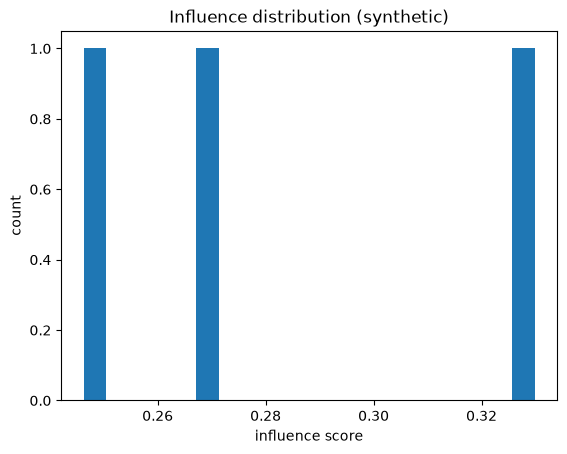

In [3]:
import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt

plt.hist(Phi[:, 0], bins=20)
plt.xlabel("influence score"); plt.ylabel("count")
plt.title("Influence distribution (synthetic)")
plt.show()